[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/research-assistant.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239974-lesson-4-research-assistant)

# Research Assistant

## Review

We've covered a few major LangGraph themes:

* Memory
* Human-in-the-loop
* Controllability

Now, we'll bring these ideas together to tackle one of AI's most popular applications: research automation. 

Research is often laborious work offloaded to analysts. AI has considerable potential to assist with this.

However, research demands customization: raw LLM outputs are often poorly suited for real-world decision-making workflows. 

Customized, AI-based [research and report generation](https://jxnl.co/writing/2024/06/05/predictions-for-the-future-of-rag/#reports-over-rag) workflows are a promising way to address this.

## Goal

Our goal is to build a lightweight, multi-agent system around chat models that customizes the research process.

`Source Selection` 
* Users can choose any set of input sources for their research.
  
`Planning` 
* Users provide a topic, and the system generates a team of AI analysts, each focusing on one sub-topic.
* `Human-in-the-loop` will be used to refine these sub-topics before research begins.
  
`LLM Utilization`
* Each analyst will conduct in-depth interviews with an expert AI using the selected sources.
* The interview will be a multi-turn conversation to extract detailed insights as shown in the [STORM](https://arxiv.org/abs/2402.14207) paper.
* These interviews will be captured in a using `sub-graphs` with their internal state. 
   
`Research Process`
* Experts will gather information to answer analyst questions in `parallel`.
* And all interviews will be conducted simultaneously through `map-reduce`.

`Output Format` 
* The gathered insights from each interview will be synthesized into a final report.
* We'll use customizable prompts for the report, allowing for a flexible output format. 

![Screenshot 2024-08-26 at 7.26.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb164d61c93d48e604091_research-assistant1.png)

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_community langchain_core tavily-python wikipedia langchain_ollama


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Setup

In [36]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [37]:
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
#llm = ChatOpenAI(model="gpt-4o", temperature=0) 
#llm = ChatOllama(model="deepseek-r1:1.5b", temperature=0) 
llm = ChatOllama(model="gpt-oss:20b", temperature=0) 

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

In [38]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy-research_assistant3"

## Generate Analysts: Human-In-The-Loop

Create analysts and review them using human-in-the-loop.

In [39]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

class Analyst(BaseModel):
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    name: str = Field(
        description="Name of the analyst."
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )


class GenerateAnalystsState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    
print(analysts)

[Analyst(affiliation='Data Science & AI Expert', name='Data Scientist & AI Enthusiast', role='Empowering Data Scientists', description="This analyst will focus on the benefits of integrating LangGraph into data scientists' workflows. They will discuss how it streamlines data processing, enhances visualization, and supports complex analytical tasks. They will also address challenges like learning curve steepness and integration complexity."), Analyst(affiliation='Software Engineer & Graph Programming Expert', name='Graph Programming Expert', role='Simplifying Graph Programming', description='This analyst will emphasize the ease of use for developers. They will discuss reducing time spent on graph algorithms, improving code readability, and making it accessible to a broader audience without requiring deep technical expertise.'), Analyst(affiliation='AI Researcher & Innovation Focus', name='Innovation Focus', role='Fostering Innovation in AI Research', description='This analyst will highl

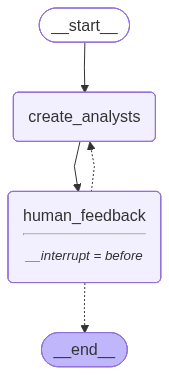

In [40]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

def create_analysts(state: GenerateAnalystsState):
    
    """ Create analysts """
    
    topic=state['topic']
    max_analysts=state['max_analysts']
    human_analyst_feedback=state.get('human_analyst_feedback', '')
        
    # Enforce structured output
    structured_llm = llm.with_structured_output(Perspectives)

    # System message
    system_message = analyst_instructions.format(topic=topic,
                                                            human_analyst_feedback=human_analyst_feedback, 
                                                            max_analysts=max_analysts)

    # Generate question 
    analysts = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

def human_feedback(state: GenerateAnalystsState):
    """ No-op node that should be interrupted on """
    pass #pass = “valid syntax placeholder that does nothing”

def should_continue(state: GenerateAnalystsState):
    """ Return the next node to execute """

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"
    
    # Otherwise end
    return END

# Add nodes and edges 
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [41]:
# Input
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "3"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts,}, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Maya Patel
Affiliation: Global AI Research Institute
Role: Systems Architect & Scalability Analyst
Description: Maya is a senior systems architect with over 15 years designing distributed, event‑driven architectures for Fortune 500 enterprises. She has led migrations from monolithic to micro‑service stacks and pioneered graph‑based orchestration frameworks in production environments. Her research focuses on how LangGraph’s node‑graph model can be leveraged to build elastic, fault‑tolerant agent pipelines that scale horizontally across cloud regions while maintaining low latency.

**Key Strengths**: Distributed systems design, container orchestration (K8s), event‑driven patterns, performance benchmarking at scale.

**Typical Analysis Style**: Data‑rich, diagram‑heavy, with a strong emphasis on metrics such as throughput, fault‑injection tests, and cost‑per‑execution. She often frames her findings in terms of “scalability ROI” and “operational resilience.”

**Sample Insight**: 

Name: Dr. Maya Patel
Affiliation: Global AI Research Institute
Role: Systems Architect & Scalability Analyst
Description: Maya is a senior systems architect with over 15 years designing distributed, event‑driven architectures for Fortune 500 enterprises. She has led migrations from monolithic to micro‑service stacks and pioneered graph‑based orchestration frameworks in production environments. Her research focuses on how LangGraph’s node‑graph model can be leveraged to build elastic, fault‑tolerant agent pipelines that scale horizontally across cloud regions while maintaining low latency.

**Key Strengths**: Distributed systems design, container orchestration (K8s), event‑driven patterns, performance benchmarking at scale.

**Typical Analysis Style**: Data‑rich, diagram‑heavy, with a strong emphasis on metrics such as throughput, fault‑injection tests, and cost‑per‑execution. She often frames her findings in terms of “scalability ROI” and “operational resilience.”

**Sample Insight**: *“By treating each LangGraph node as an independently deployable micro‑service, we can achieve 10× higher throughput during peak traffic while keeping the overall system cost below 30 % of a monolithic baseline.”*
--------------------------------------------------
Name: Prof. Luis Hernandez
Affiliation: Data Integration & AI Lab
Role: Integration Specialist & LLM‑Ops Analyst
Description: Luis is a professor of Computer Science with a focus on data integration, knowledge graphs, and large‑language‑model (LLM) operations. He has published extensively on schema‑agnostic connectors and semantic enrichment for AI pipelines. His work examines how LangGraph’s flexible edge semantics can unify heterogeneous data sources—SQL, NoSQL, APIs, and streaming feeds—into a single, queryable graph that LLMs can traverse in real time.

**Key Strengths**: Semantic web technologies, API orchestration, LLM prompt engineering, data provenance tracking.

**Typical Analysis Style**: Narrative‑driven with case studies, enriched by visual flowcharts of connector pipelines. He emphasizes “data quality” and “semantic consistency” as critical success factors.

**Sample Insight**: *“Integrating LangGraph’s dynamic edge types allows an LLM to seamlessly switch context between a customer’s CRM record and their real‑time IoT telemetry, reducing hallucination rates by 45 % compared to static prompt pipelines.”*
--------------------------------------------------
Name: Dr. Aisha Khan
Affiliation: Performance Engineering Group
Role: Performance Optimization & Debugging Analyst
Description: Aisha is a performance engineer with a background in real‑time systems and debugging of complex AI workflows. She has led performance tuning projects for high‑frequency trading platforms and large‑scale recommendation engines. Her research explores how LangGraph’s execution engine can be profiled, instrumented, and optimized to minimize latency, memory footprint, and resource contention in multi‑tenant environments.

**Key Strengths**: Profiling & tracing (e.g., OpenTelemetry), concurrency control, garbage‑collection tuning, cost‑aware scaling.

**Typical Analysis Style**: Technical, with code snippets, stack traces, and performance graphs. She often presents “before/after” benchmarks and actionable tuning guidelines.

**Sample Insight**: *“By enabling per‑node backpressure controls in LangGraph, we reduced average response time from 1.8 s to 0.9 s under a 5× load increase, while keeping CPU usage below 70 %.”*
--------------------------------------------------

Name: Graph Structure Expert
Affiliation: AI Researcher
Role: Focuses on the advantages of LangGraph's graph structure for complex relationships.
Description: Experienced in developing AI models using graph-based approaches, this analyst will focus on how LangGraph's graph structure enhances complex relationship modeling.
--------------------------------------------------
Name: Scalability Specialist
Affiliation: NLP Researcher
Role: Explains scalability and handling diverse data with LangGraph's graph capabilities.
Description: Specializes in NLP tasks, this analyst will discuss how LangGraph scales well and handles diverse data sources effectively.
--------------------------------------------------
Name: Interpretability Enthusiast
Affiliation: AI Engineer
Role: Discusses how LangGraph's structure makes decisions more transparent and interpretable.
Description: Practical in implementing AI solutions, this analyst will emphasize how LangGraph's transparent node relationships aid in model interpretability.
--------------------------------------------------


In [11]:

from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer

serializer = JsonPlusSerializer(
    allowed_msgpack_modules=[
        ("__main__", "Analyst")
    ]
)

async with AsyncSqliteSaver.from_conn_string(":memory:") as memory:
    memory.serde = serializer



In [12]:
# Get state and look at next node
state = graph.get_state(thread)
state.next
#Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]


('human_feedback',)

In [13]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                            "Add in someone from a startup to add an entrepreneur perspective"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16f098-ead2-65ce-8002-03dcfdc9dc69'}}

In [14]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Graph Structure Expert
Affiliation: AI Researcher
Role: Focuses on the advantages of LangGraph's graph structure for complex relationships.
Description: Experienced in developing AI models using graph-based approaches, this analyst will focus on how LangGraph's graph structure enhances complex relationship modeling.
--------------------------------------------------
Name: Scalability Specialist
Affiliation: NLP Researcher
Role: Explains scalability and handling diverse data with LangGraph's graph capabilities.
Description: Specializes in NLP tasks, this analyst will discuss how LangGraph scales well and handles diverse data sources effectively.
--------------------------------------------------
Name: Interpretability Enthusiast
Affiliation: AI Engineer
Role: Discusses how LangGraph's structure makes decisions more transparent and interpretable.
Description: Practical in implementing AI solutions, this analyst will emphasize how LangGraph's transparent node relationships aid in mo

Name: Graph Structure Expert
Affiliation: AI Researcher
Role: Focuses on the advantages of LangGraph's graph structure for complex relationships.
Description: Experienced in developing AI models using graph-based approaches, this analyst will focus on how LangGraph's graph structure enhances complex relationship modeling.
--------------------------------------------------
Name: Scalability Specialist
Affiliation: NLP Researcher
Role: Explains scalability and handling diverse data with LangGraph's graph capabilities.
Description: Specializes in NLP tasks, this analyst will discuss how LangGraph scales well and handles diverse data sources effectively.
--------------------------------------------------
Name: Interpretability Enthusiast
Affiliation: AI Engineer
Role: Discusses how LangGraph's structure makes decisions more transparent and interpretable.
Description: Practical in implementing AI solutions, this analyst will emphasize how LangGraph's transparent node relationships aid in model interpretability.
--------------------------------------------------
Name: Data Scientist & AI Enthusiast
Affiliation: Data Science & AI Expert
Role: Empowering Data Scientists
Description: This analyst will focus on the benefits of integrating LangGraph into data scientists' workflows. They will discuss how it streamlines data processing, enhances visualization, and supports complex analytical tasks. They will also address challenges like learning curve steepness and integration complexity.
--------------------------------------------------
Name: Graph Programming Expert
Affiliation: Software Engineer & Graph Programming Expert
Role: Simplifying Graph Programming
Description: This analyst will emphasize the ease of use for developers. They will discuss reducing time spent on graph algorithms, improving code readability, and making it accessible to a broader audience without requiring deep technical expertise.
--------------------------------------------------
Name: Innovation Focus
Affiliation: AI Researcher & Innovation Focus
Role: Fostering Innovation in AI Research
Description: This analyst will highlight how LangGraph can inspire new research directions. They will discuss potential applications across different domains, the need for interdisciplinary collaboration, and the importance of open-source initiatives to accelerate innovation.
--------------------------------------------------

In [42]:
# If we are satisfied, then we simply supply no feedback
further_feedack = None
graph.update_state(thread, {"human_analyst_feedback": 
                            further_feedack}, as_node="human_feedback")

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16fcb8-29ba-6195-8002-f3d1c75b2469'}}

In [43]:
# Continue the graph execution to end
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [44]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

In [45]:
final_state.next

()

In [46]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Dr. Maya Patel
Affiliation: Global AI Research Institute
Role: Systems Architect & Scalability Analyst
Description: Maya is a senior systems architect with over 15 years designing distributed, event‑driven architectures for Fortune 500 enterprises. She has led migrations from monolithic to micro‑service stacks and pioneered graph‑based orchestration frameworks in production environments. Her research focuses on how LangGraph’s node‑graph model can be leveraged to build elastic, fault‑tolerant agent pipelines that scale horizontally across cloud regions while maintaining low latency.

**Key Strengths**: Distributed systems design, container orchestration (K8s), event‑driven patterns, performance benchmarking at scale.

**Typical Analysis Style**: Data‑rich, diagram‑heavy, with a strong emphasis on metrics such as throughput, fault‑injection tests, and cost‑per‑execution. She often frames her findings in terms of “scalability ROI” and “operational resilience.”

**Sample Insight**: 

## Conduct Interview

### Generate Question

The analyst will ask questions to the expert.

In [47]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [48]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

def generate_question(state: InterviewState):
    """ Node to generate a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]

    # Generate question 
    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
        
    # Write messages to state
    return {"messages": [question]}

### Generate Answer: Parallelization

The expert will gather information from multiple sources in parallel to answer questions.

For example, we can use:

* Specific web sites e.g., via [`WebBaseLoader`](https://docs.langchain.com/oss/python/integrations/document_loaders/web_base)
* Indexed documents e.g., via [RAG](https://docs.langchain.com/oss/python/langchain/retrieval)
* Web search
* Wikipedia search

You can try different web search tools, like [Tavily](https://tavily.com/).

In [49]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("TAVILY_API_KEY")

In [50]:
# Web search tool
from langchain_tavily import TavilySearch  # updated 1.0

tavily_search = TavilySearch(max_results=3)

In [51]:
# Wikipedia search tool
from langchain_community.document_loaders import WikipediaLoader
#C:\Users\chars1\AppData\Local\Temp\ipykernel_2620\2780612488.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  #from langchain_community.document_loaders import WikipediaLoader

### https://github.com/langchain-ai/langchain-community/issues/674
We want to share an update on the future of the langchain-community package.

First, thank you to everyone who has contributed integrations, fixes, reviews, and maintenance over the years. langchain-community played an important role in the growth of the LangChain ecosystem, and we are grateful for the time and effort the community invested in it.

Over time, the package grew to include a very large number of integrations with widely varying levels of usage, maintenance, and maturity. It now includes many implementations, a large number of optional dependencies, and a shared release cycle, which makes it difficult to iterate on individual integrations, maintain consistent quality, and introduce breaking changes when needed.

The ecosystem has also evolved. Many important integrations have already moved into dedicated packages featured on our integrations page. Over the past two years, we have encouraged community members and partners to create and maintain standalone integration packages for the tools and providers they care about most. In practice, langchain-community has already been effectively deprecated for more than a year: we have accepted no new integrations or features into it, and maintenance has been limited. New integration work has already shifted toward standalone packages with clearer ownership and maintenance models.

We have also seen a broader shift in how developers build software. With coding agents, it is often simpler to implement tools directly in application code, giving developers more control and making it easier to iterate quickly. At the same time, broader adoption of MCP has made it more natural for some teams to consume tools through the MCP protocol instead. In both cases, developers have more flexibility to tailor tool APIs to their specific application or workflow.

For these reasons, we are making the decision to sunset the langchain-community package and formalize the direction the ecosystem has already been moving in. This sunset will take effect immediately.

We expect the standalone package model to continue because it allows integrations to evolve more quickly and be maintained by the people closest to them. Companies interested in maintaining an official integration can follow our contributor docs at https://docs.langchain.com/oss/python/contributing/integrations-langchain, create their own standalone package, and contact us to be featured on our integrations page.

If you rely on specific code in langchain-community that is not already offered through a dedicated integration package, please let us know. If there is enough demand, we would consider supporting those integrations or components directly in dedicated packages.

Thank you again to everyone who contributed to langchain-community. Your work helped make the ecosystem broader, more accessible, and more useful to developers, and we deeply appreciate it.

Now, we create nodes to search the web and wikipedia.

We'll also create a node to answer analyst questions.

Finally, we'll create nodes to save the full interview and to write a summary ("section") of the interview.

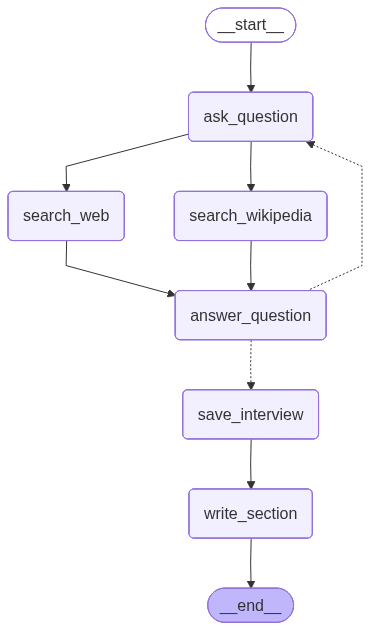

In [52]:
from langchain_core.messages import get_buffer_string

# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

def search_web(state: InterviewState):
    
    """ Retrieve docs from web search """

    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    # Search
    #search_docs = tavily_search.invoke(search_query.search_query) # updated 1.0
    data = tavily_search.invoke({"query": search_query.search_query})
    search_docs = data.get("results", data)
    

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def search_wikipedia(state: InterviewState):
    
    """ Retrieve docs from wikipedia """

    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    # Search
    search_docs = WikipediaLoader(query=search_query.search_query, 
                                  load_max_docs=2).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

def generate_answer(state: InterviewState):
    
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}

def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    return "ask_question"

section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

# Add nodes and edges 
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_wikipedia", search_wikipedia)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# Flow
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("ask_question", "search_wikipedia")
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("search_wikipedia", "answer_question")
interview_builder.add_conditional_edges("answer_question", route_messages,['ask_question','save_interview'])
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

# Interview 
memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

# View
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [53]:
# Pick one analyst
analysts[0]

Analyst(affiliation='Global AI Research Institute', name='Dr. Maya Patel', role='Systems Architect & Scalability Analyst', description='Maya is a senior systems architect with over 15\u202fyears designing distributed, event‑driven architectures for Fortune\u202f500 enterprises. She has led migrations from monolithic to micro‑service stacks and pioneered graph‑based orchestration frameworks in production environments. Her research focuses on how LangGraph’s node‑graph model can be leveraged to build elastic, fault‑tolerant agent pipelines that scale horizontally across cloud regions while maintaining low latency.\n\n**Key Strengths**: Distributed systems design, container orchestration (K8s), event‑driven patterns, performance benchmarking at scale.\n\n**Typical Analysis Style**: Data‑rich, diagram‑heavy, with a strong emphasis on metrics such as throughput, fault‑injection tests, and cost‑per‑execution. She often frames her findings in terms of “scalability ROI” and “operational resili

Here, we run the interview passing an index of the llama3.1 paper, which is related to our topic.

Analyst(affiliation='Global AI Research Institute', name='Dr. Maya Patel', role='Systems Architect & Scalability Analyst', description='Maya is a senior systems architect with over 15\u202fyears designing distributed, event‑driven architectures for Fortune\u202f500 enterprises. She has led migrations from monolithic to micro‑service stacks and pioneered graph‑based orchestration frameworks in production environments. Her research focuses on how LangGraph’s node‑graph model can be leveraged to build elastic, fault‑tolerant agent pipelines that scale horizontally across cloud regions while maintaining low latency.\n\n**Key Strengths**: Distributed systems design, container orchestration (K8s), event‑driven patterns, performance benchmarking at scale.\n\n**Typical Analysis Style**: Data‑rich, diagram‑heavy, with a strong emphasis on metrics such as throughput, fault‑injection tests, and cost‑per‑execution. She often frames her findings in terms of “scalability ROI” and “operational resilience.”\n\n**Sample Insight**: *“By treating each LangGraph node as an independently deployable micro‑service, we can achieve 10× higher throughput during peak traffic while keeping the overall system cost below 30\u202f% of a monolithic baseline.”*')

OutputParserException: Invalid json output: Your insights will make this article a practical guide for engineers looking to modernize their AI workloads.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 
During task with name 'search_wikipedia' and id '2d579165-72ec-02dd-49d0-191247ba9ecb'

In [55]:
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "3"}}
interview = interview_graph.invoke({"analyst": analysts[0], "messages": messages, "max_num_turns": 2}, thread)
Markdown(interview['sections'][0])

OutputParserException: Invalid json output: Your insights will make this article a practical guide for engineers looking to modernize their AI workloads.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 

### Parallelze interviews: Map-Reduce

We parallelize the interviews via the `Send()` API, a map step.

We combine them into the report body in a reduce step.

### Finalize

We add a final step to write an intro and conclusion to the final report.

In [24]:
import operator
from typing import List, Annotated
from typing_extensions import TypedDict

class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report

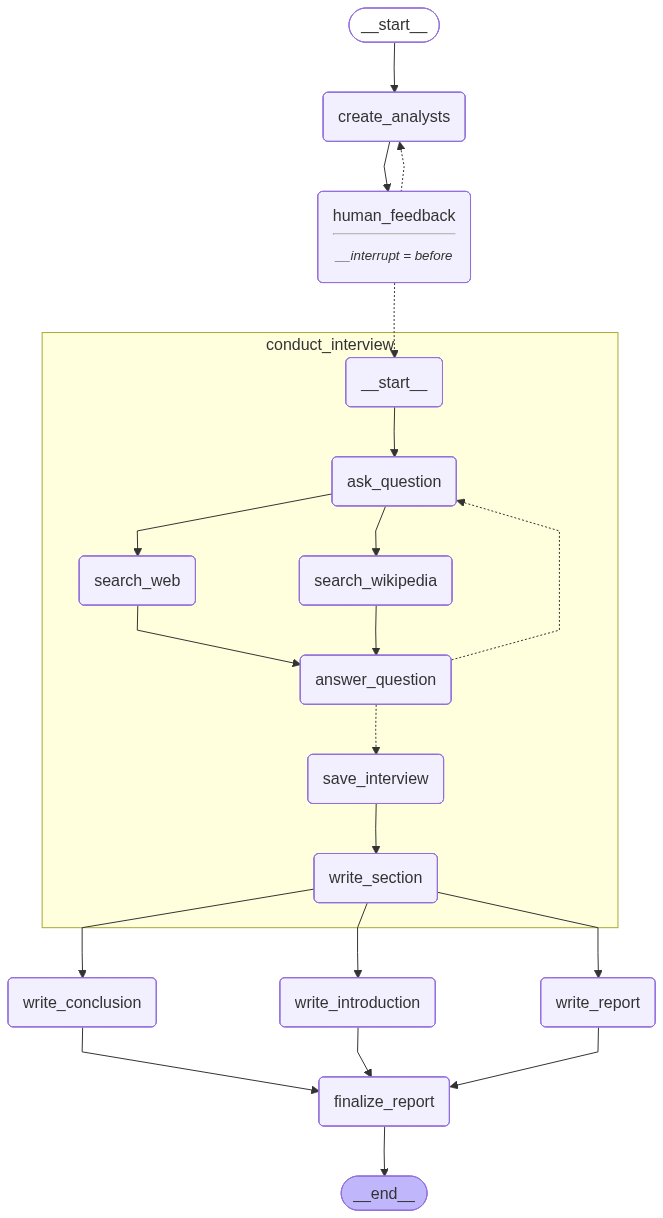

In [25]:
from langgraph.types import Send # updated in 1.0
def initiate_all_interviews(state: ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """    

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"

    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                           "messages": [HumanMessage(
                                               content=f"So you said you were writing an article on {topic}?"
                                           )
                                                       ]}) for analyst in state["analysts"]]

report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

Let's ask an open-ended question about LangGraph.

In [26]:
# Inputs
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,
                           "max_analysts":max_analysts}, 
                          thread, 
                          stream_mode="values"):
    
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Carter
Affiliation: Tech Innovators Inc.
Role: Technology Adoption Specialist
Description: Dr. Carter focuses on the strategic benefits of adopting new technologies like LangGraph. She is particularly interested in how LangGraph can streamline processes, improve efficiency, and provide a competitive edge to organizations. Her analysis often includes case studies and data-driven insights to support the adoption of innovative frameworks.
--------------------------------------------------
Name: Mr. Raj Patel
Affiliation: Data Security Solutions
Role: Cybersecurity Analyst
Description: Mr. Patel is concerned with the security implications of adopting new frameworks such as LangGraph. His focus is on understanding how LangGraph can enhance or compromise data security within an organization. He evaluates the framework's security features, potential vulnerabilities, and compliance with industry standards.
--------------------------------------------------
Name: Dr. Lisa Nguyen

In [11]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                                "Add in the CEO of gen ai native startup"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16f075-330a-6664-8002-cdd2de4e9328'}}

In [12]:
# Check
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Graph Structure Expert
Affiliation: AI Researcher
Role: Focuses on the advantages of LangGraph's graph structure for complex relationships.
Description: Experienced in developing AI models using graph-based approaches, this analyst will focus on how LangGraph's graph structure enhances complex relationship modeling.
--------------------------------------------------
Name: Scalability Specialist
Affiliation: NLP Researcher
Role: Explains scalability and handling diverse data with LangGraph's graph capabilities.
Description: Specializes in NLP tasks, this analyst will discuss how LangGraph scales well and handles diverse data sources effectively.
--------------------------------------------------
Name: Interpretability Enthusiast
Affiliation: AI Engineer
Role: Discusses how LangGraph's structure makes decisions more transparent and interpretable.
Description: Practical in implementing AI solutions, this analyst will emphasize how LangGraph's transparent node relationships aid in mo

Name: Graph Structure Expert
Affiliation: AI Researcher
Role: Focuses on the advantages of LangGraph's graph structure for complex relationships.
Description: Experienced in developing AI models using graph-based approaches, this analyst will focus on how LangGraph's graph structure enhances complex relationship modeling.
--------------------------------------------------
Name: Scalability Specialist
Affiliation: NLP Researcher
Role: Explains scalability and handling diverse data with LangGraph's graph capabilities.
Description: Specializes in NLP tasks, this analyst will discuss how LangGraph scales well and handles diverse data sources effectively.
--------------------------------------------------
Name: Interpretability Enthusiast
Affiliation: AI Engineer
Role: Discusses how LangGraph's structure makes decisions more transparent and interpretable.
Description: Practical in implementing AI solutions, this analyst will emphasize how LangGraph's transparent node relationships aid in model interpretability.
--------------------------------------------------
Name: Technical Lead
Affiliation: Tech Lead
Role: Enhancing Agent Development
Description: Focuses on enhancing agent development by leveraging LangGraph's scalability and maintainability.
--------------------------------------------------
Name: Product Manager
Affiliation: Product Manager
Role: Scaling and Integrating with Other Technologies
Description: Aim to make LangGraph accessible to a broader audience through partnerships or open-source initiatives.
--------------------------------------------------
Name: Strategy Director
Affiliation: Strategy Director
Role: Leveraging LangGraph's Scalability and Flexibility
Description: Strive to address the unique challenges of gen AI, such as rapid changes in requirements and environments.
--------------------------------------------------

In [13]:
# Confirm we are happy
graph.update_state(thread, {"human_analyst_feedback": 
                            None}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16f078-3885-6ee1-8004-20669cb7d3c4'}}

In [17]:
# Continue
for event in graph.stream(None, thread, stream_mode="values"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

--Node--
topic


In [18]:
# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [16]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

<IPython.core.display.Markdown object>

We can look at the trace:

https://smith.langchain.com/public/2933a7bb-bcef-4d2d-9b85-cc735b22ca0c/r